# Knapsack Benchmark — Post-Benchmark Analysis

**Phase 3:** Scatter plots of `time_sec` vs each attribute per algorithm.
**Phase 4:** Automated curve fitting (shape detection) on `time_sec` vs `n`.

In [1]:
from __future__ import annotations
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    from scipy.optimize import curve_fit
    from scipy.stats import pearsonr
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Design ───────────────────────────────────────────────────────────────────
FIG_BG    = "#0f0f1a"
AX_BG     = "#16213e"
GRID_CLR  = "#2a2a4a"
TEXT_CLR  = "#dde1f0"
MUTED_CLR = "#8890b0"
PAL_LIST  = ["#7b68ee", "#00d4aa", "#ff6b6b", "#ffd166", "#06d6a0",
             "#ef476f", "#118ab2", "#fca311", "#e9c46a"]

plt.rcParams.update({
    "figure.facecolor": FIG_BG, "axes.facecolor": AX_BG,
    "axes.edgecolor": GRID_CLR, "axes.labelcolor": MUTED_CLR,
    "axes.grid": True, "grid.color": GRID_CLR,
    "grid.linewidth": 0.5, "grid.linestyle": "--",
    "text.color": TEXT_CLR,
    "xtick.color": MUTED_CLR, "ytick.color": MUTED_CLR,
    "legend.framealpha": 0.85, "legend.edgecolor": GRID_CLR,
    "legend.facecolor": AX_BG, "legend.labelcolor": TEXT_CLR,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.dpi": 120, "savefig.dpi": 300,
})

def style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title, color=TEXT_CLR, pad=8)
    ax.set_xlabel(xlabel, color=MUTED_CLR)
    ax.set_ylabel(ylabel, color=MUTED_CLR)
    ax.set_axisbelow(True)

def algo_pal(algos):
    return {a: PAL_LIST[i % len(PAL_LIST)] for i, a in enumerate(sorted(algos))}

def resolve_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, cwd.parent]:
        if (p / "results").exists():
            return p
    return cwd

ROOT  = resolve_root()
PLOTS = ROOT / "results" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(PLOTS / name, dpi=300, bbox_inches="tight", facecolor=FIG_BG)
    print(f"Saved -> {PLOTS / name}")

print("Root:", ROOT)

Root: E:\Antigravity Workspace\Knapsack\KnapsackOptimization


## 1 · Load & Preprocess

In [2]:
CSV_PATH = ROOT / "results" / "csv" / "benchmark_results.csv"
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

for col in ["time_sec","peak_memory_mb","optimal_value",
            "n","capacity","capacity_to_weight_ratio",
            "pearson_corr","density_variance"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

TIMEOUT = int(os.getenv("BENCHMARK_TIMEOUT_SEC", "60"))
df["is_timeout"] = df["status"].str.upper().eq("TIMEOUT")
df["is_error"]   = df["status"].str.upper().eq("ERROR")
df["is_success"] = df["status"].str.upper().eq("SUCCESS")
df["time_plot"]  = df["time_sec"].copy()
df.loc[df["is_timeout"], "time_plot"] = TIMEOUT

ALGOS = sorted(df["algorithm"].unique())
PAL   = algo_pal(ALGOS)

print(f"Rows: {len(df)}  |  Algorithms: {ALGOS}")
print(f"Timeouts: {df['is_timeout'].sum()}  |  Errors: {df['is_error'].sum()}")
display(df[["algorithm","n","time_sec","status"]].head(8))

Rows: 8220  |  Algorithms: ['Backtracking', 'BranchAndBound', 'DP', 'DPUnbounded', 'DualSimplex', 'GomoryCut', 'Greedy01', 'GreedyFractional', 'PrimalSimplex', 'SimplexBnB']
Timeouts: 3363  |  Errors: 52


,algorithm,n,time_sec,status
0,DP,15,0.00436,SUCCESS
1,BranchAndBound,15,0.00016,SUCCESS
2,Backtracking,15,0.00038,SUCCESS
3,GomoryCut,15,3.76472,SUCCESS
4,SimplexBnB,15,2.15903,SUCCESS
5,GreedyFractional,15,0.00010,SUCCESS
6,PrimalSimplex,15,0.02054,SUCCESS
7,DualSimplex,15,0.02061,SUCCESS


## 2 · Scatter Plots: time vs (n, capacity_ratio, pearson_r)

3 separate scatter plots per algorithm.
**Excludes TIMEOUT and ERROR** to avoid skewing.
Y-axis uses log scale when variance is large.

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_Backtracking.png


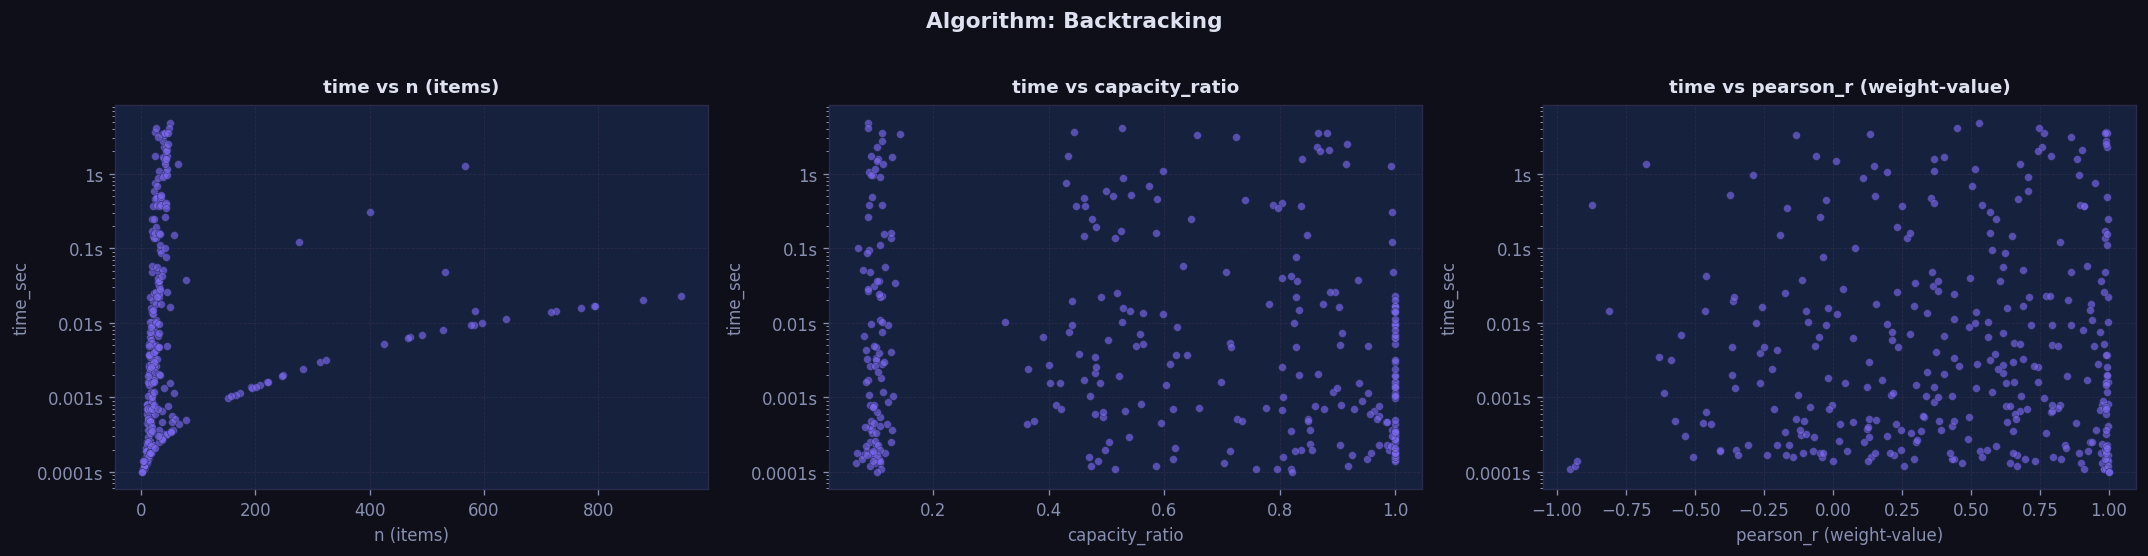

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_BranchAndBound.png


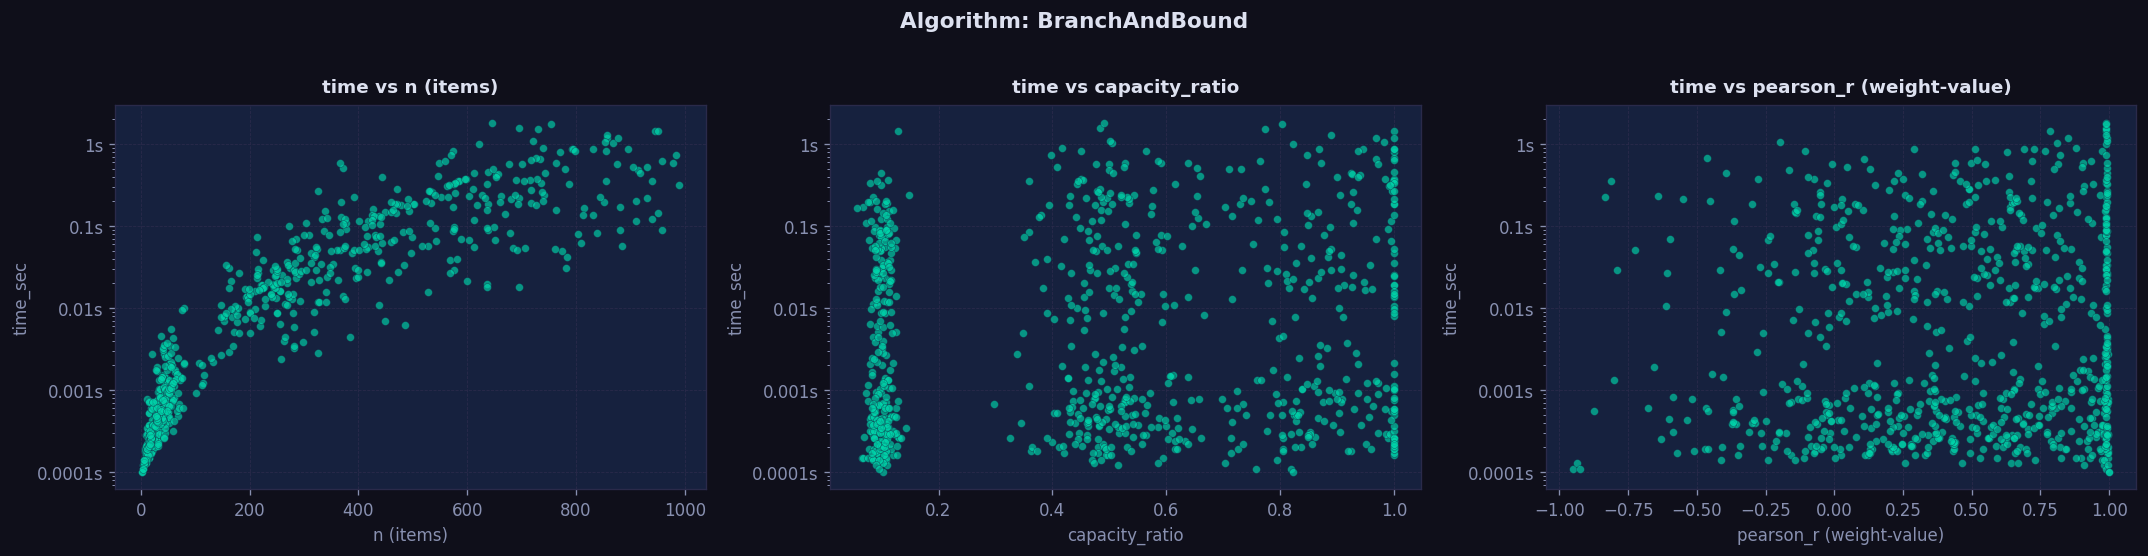

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_DP.png


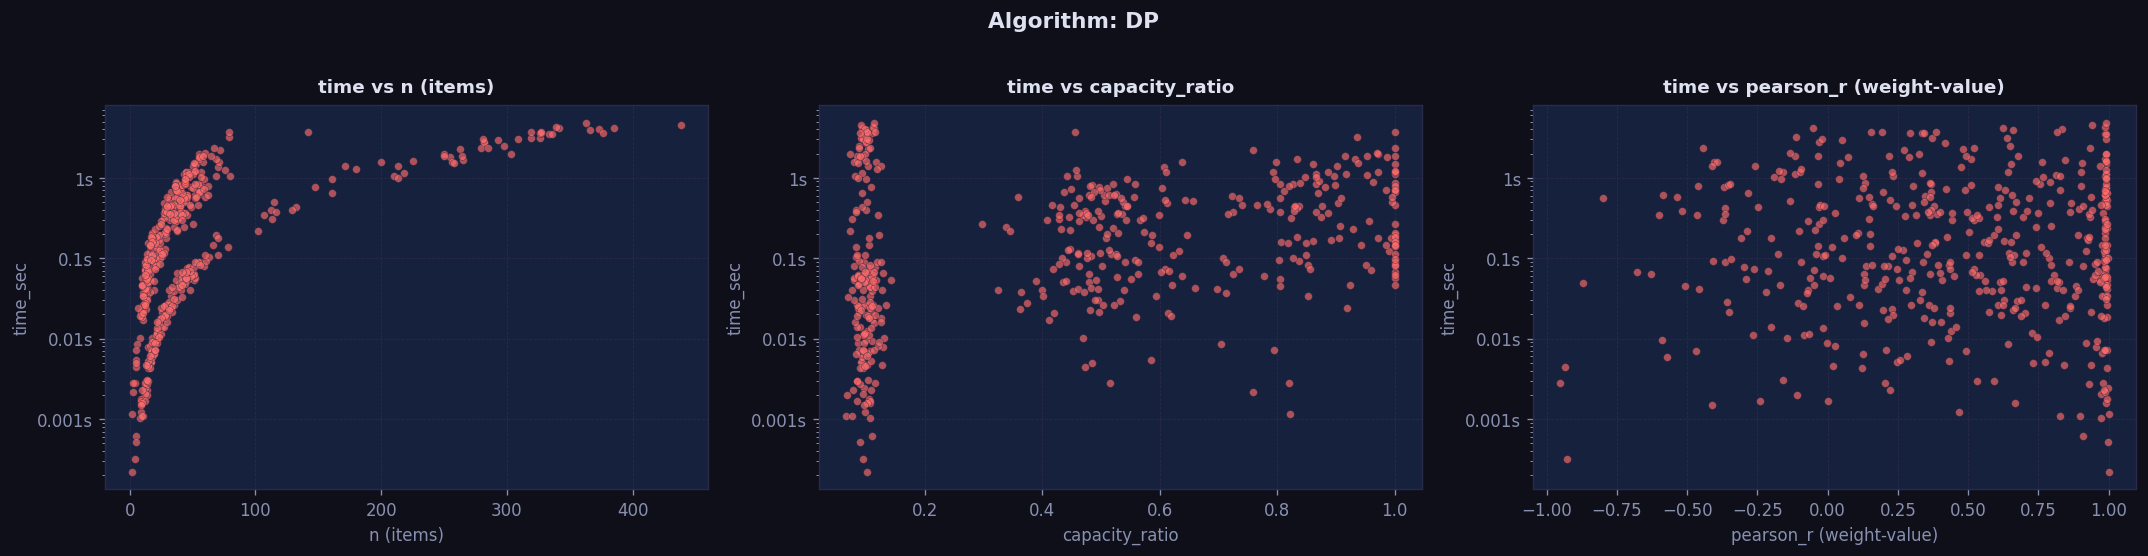

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_DPUnbounded.png


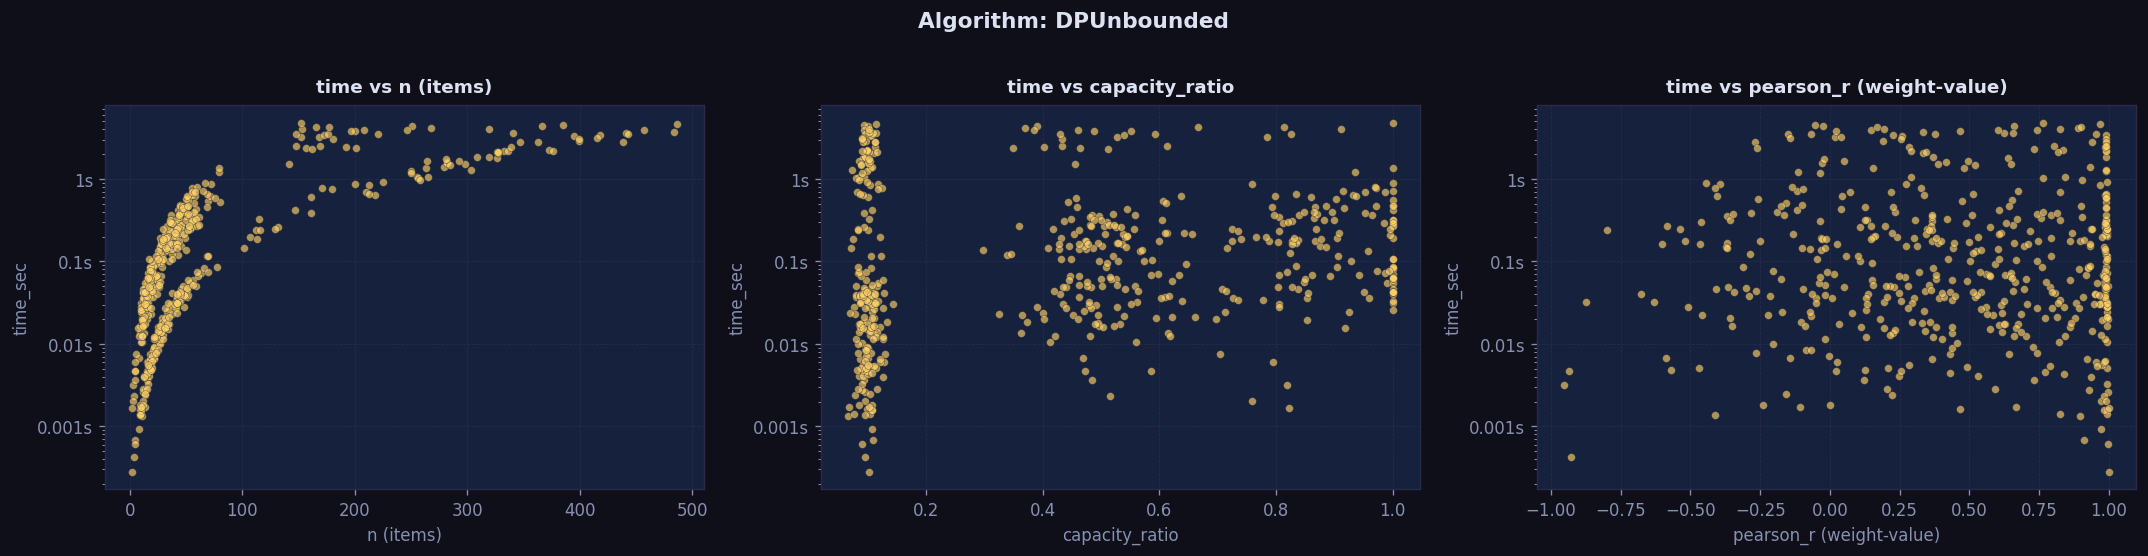

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_DualSimplex.png


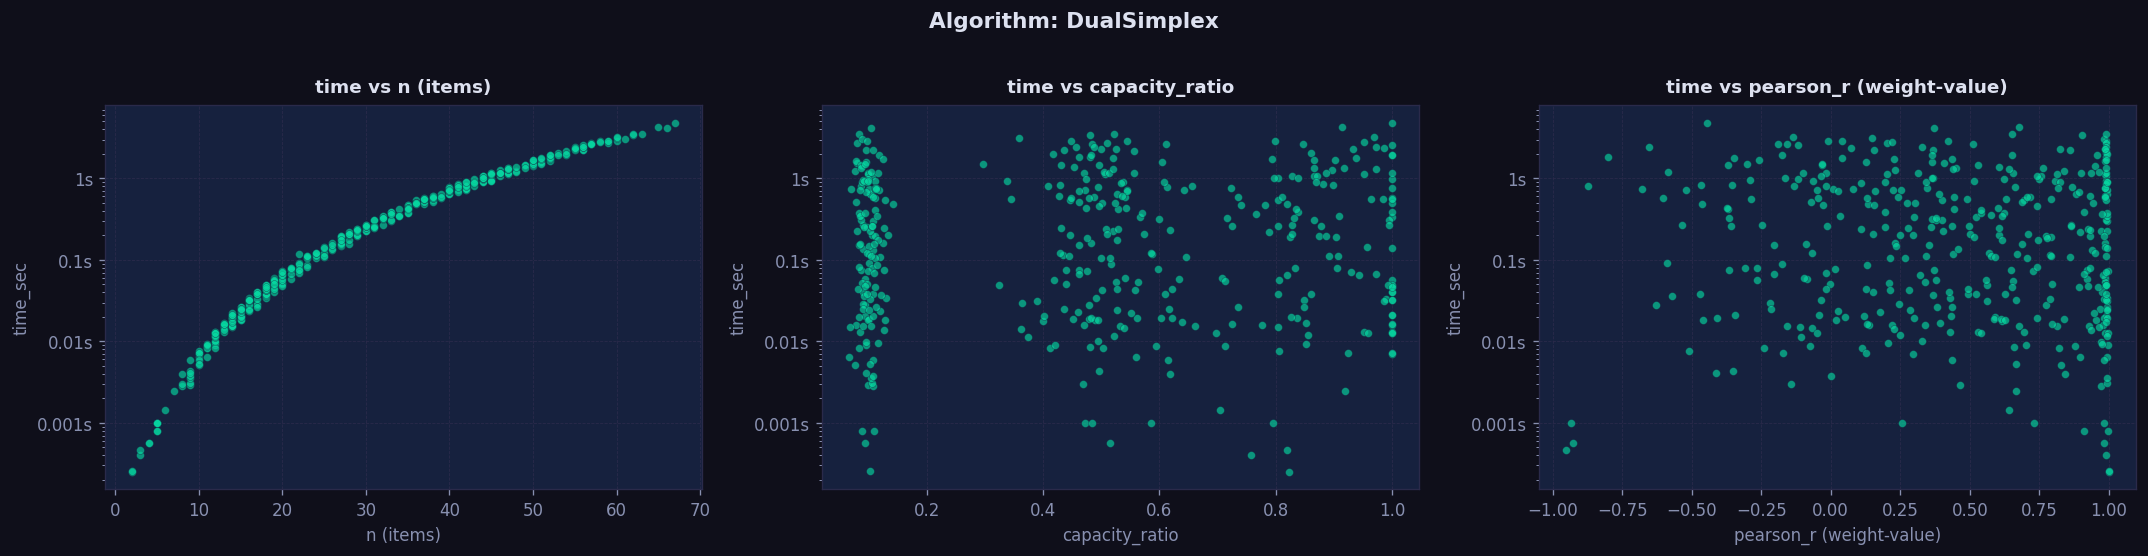

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_GomoryCut.png


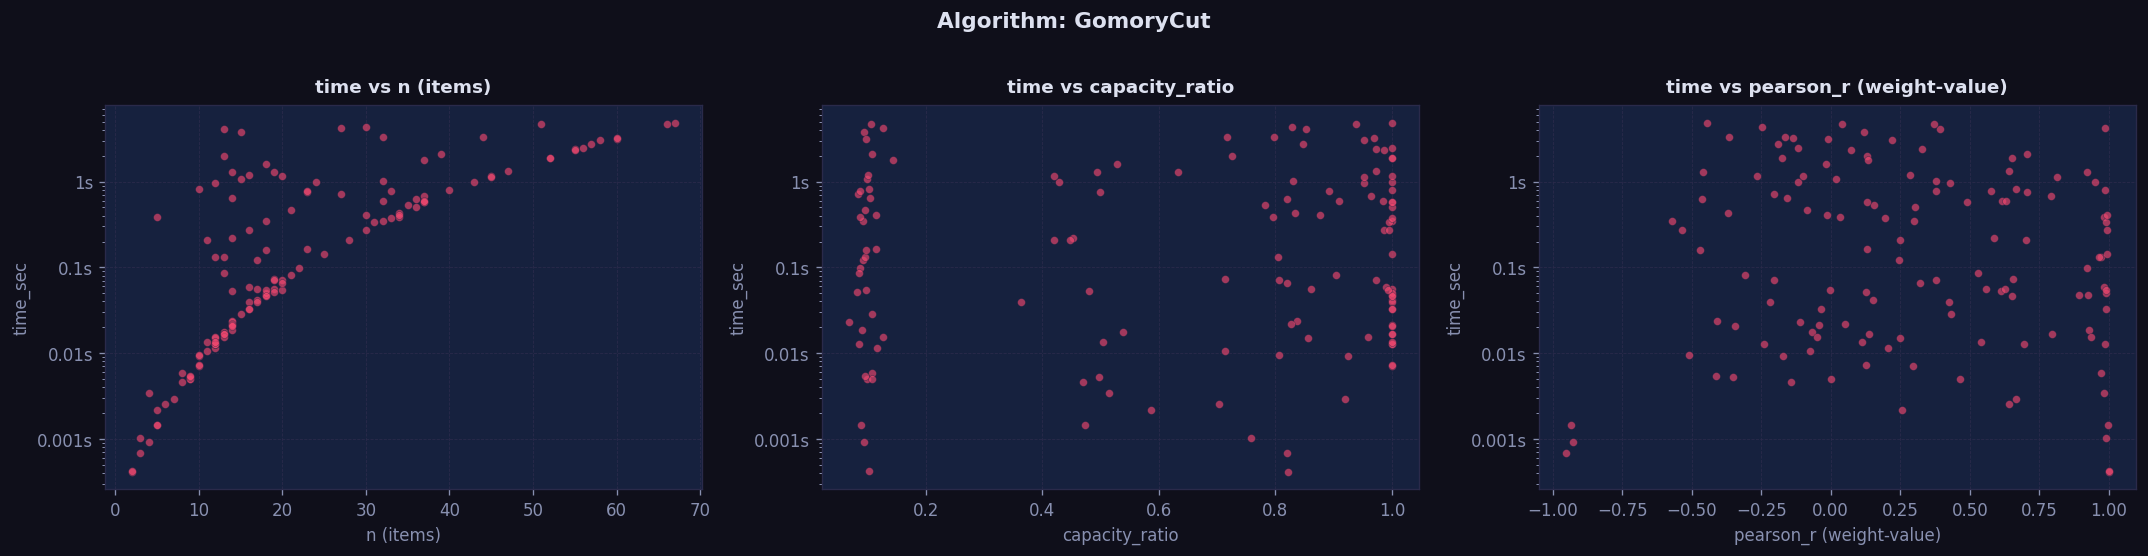

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_Greedy01.png


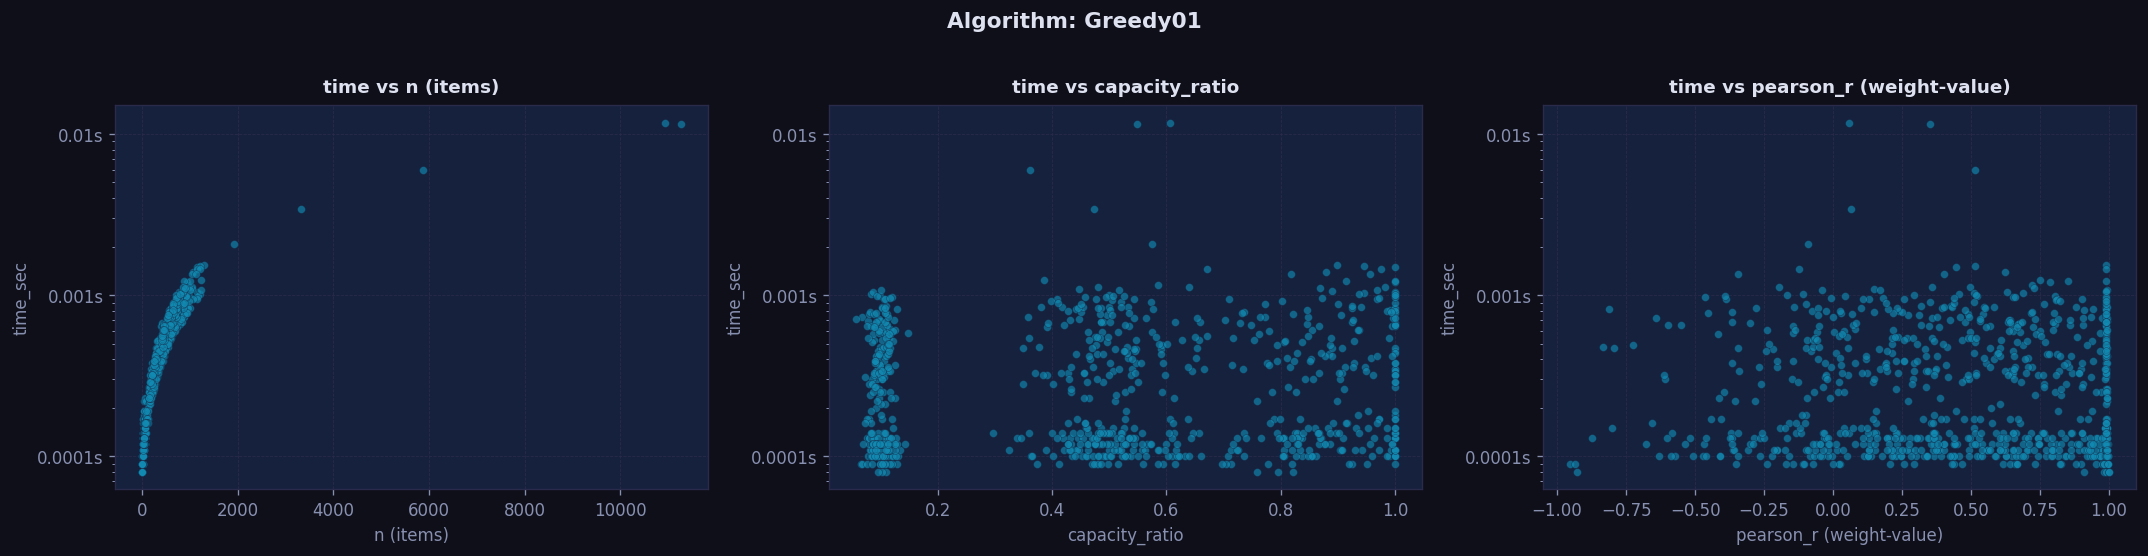

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_GreedyFractional.png


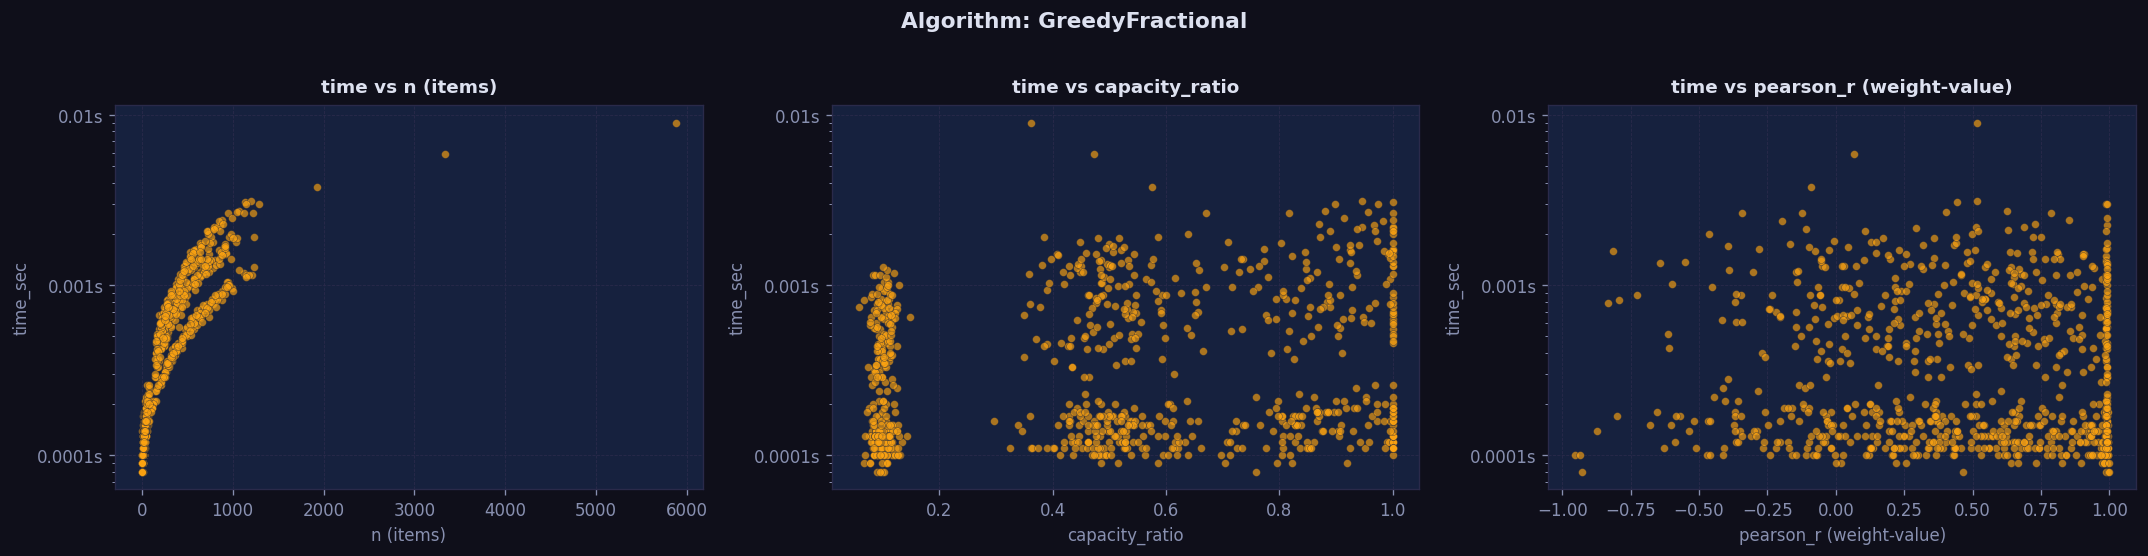

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_PrimalSimplex.png


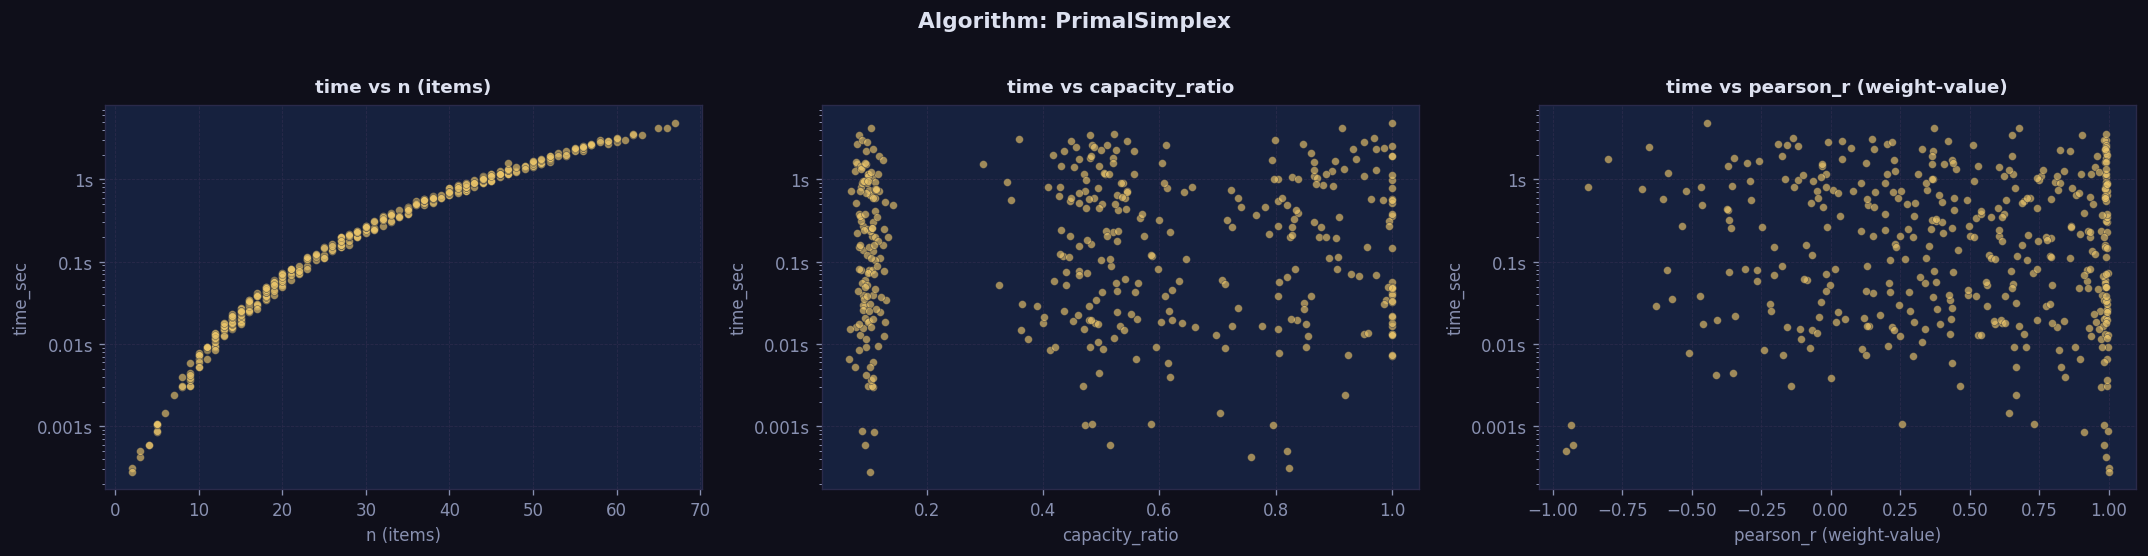

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\scatter_SimplexBnB.png


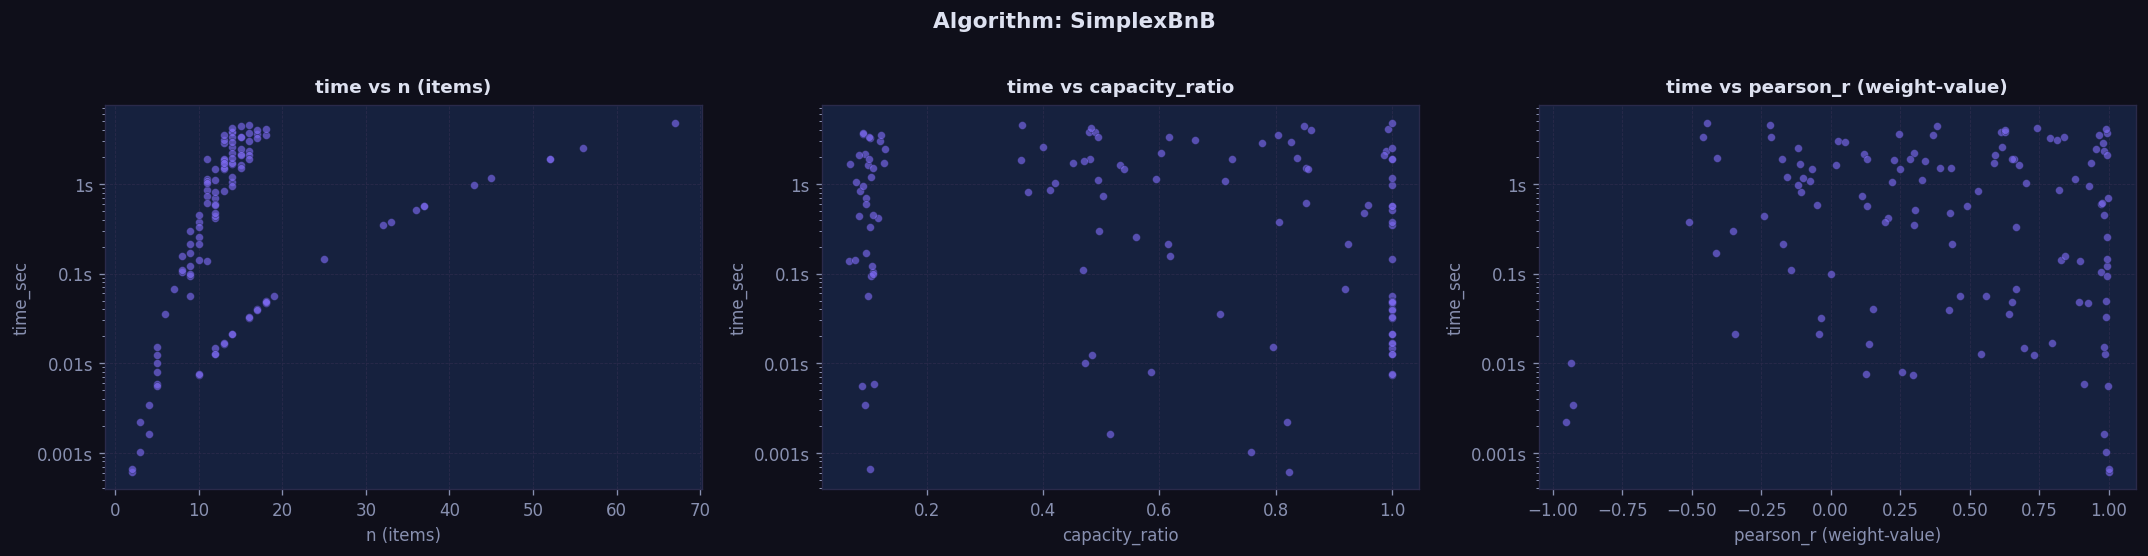

In [3]:
df_ok = df[df["is_success"]].copy()

ATTRS = [
    ("n",                          "n (items)"),
    ("capacity_to_weight_ratio",   "capacity_ratio"),
    ("pearson_corr",               "pearson_r (weight-value)"),
]

for algo in ALGOS:
    sub = df_ok[df_ok["algorithm"] == algo]
    if sub.empty:
        print(f"  {algo}: no SUCCESS rows, skip")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), facecolor=FIG_BG)
    fig.suptitle(f"Algorithm: {algo}",
                 color=TEXT_CLR, fontsize=13, fontweight="bold", y=1.02)

    for ax, (col, xlabel) in zip(axes, ATTRS):
        if col not in sub.columns or sub[col].isna().all():
            ax.text(0.5, 0.5, f"No '{col}' data", ha="center",
                    va="center", color=TEXT_CLR, transform=ax.transAxes)
            style_ax(ax, f"time vs {xlabel}", xlabel, "time_sec")
            continue

        ax.scatter(sub[col], sub["time_sec"],
                   s=22, alpha=0.65, color=PAL[algo],
                   linewidths=0.3, edgecolors=AX_BG, zorder=3)

        # Log scale if variance > 2 orders of magnitude
        tmin, tmax = sub["time_sec"].min(), sub["time_sec"].max()
        if tmax > 0 and tmin > 0 and (tmax / tmin) > 100:
            ax.set_yscale("log")
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _: f"{v:.2g}s")
            )

        style_ax(ax, f"time vs {xlabel}", xlabel, "time_sec")

    fig.tight_layout()
    save(fig, f"scatter_{algo}.png")
    plt.show()

## 3 · Curve Fitting: time vs n (shape detection)

For each algorithm, fit **Linear, Quadratic, Cubic, Exponential** candidates
to the median runtime per n.  Pick the best R² and annotate the plot.

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_Backtracking.png


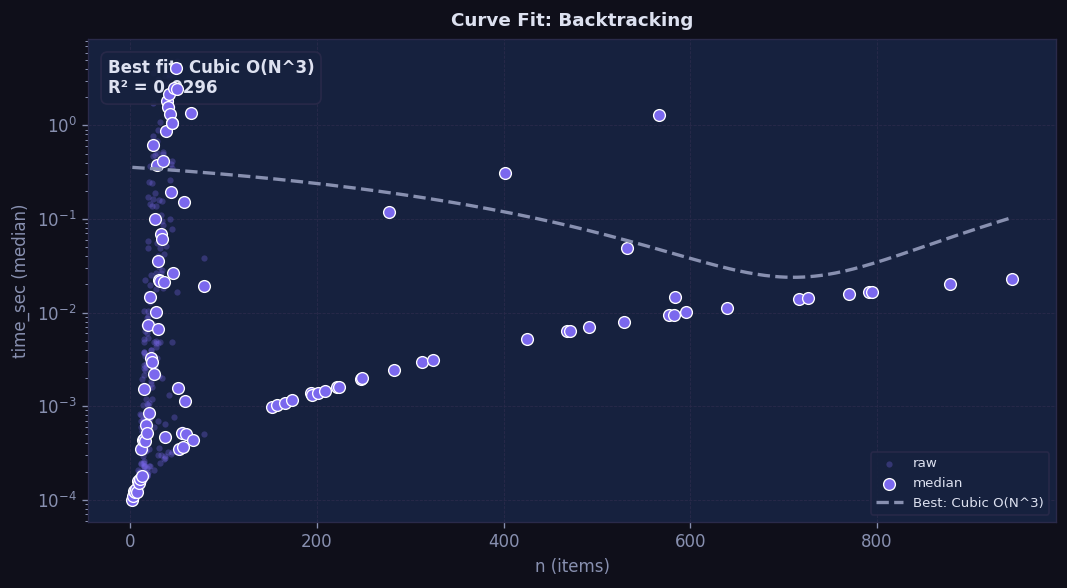

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_BranchAndBound.png


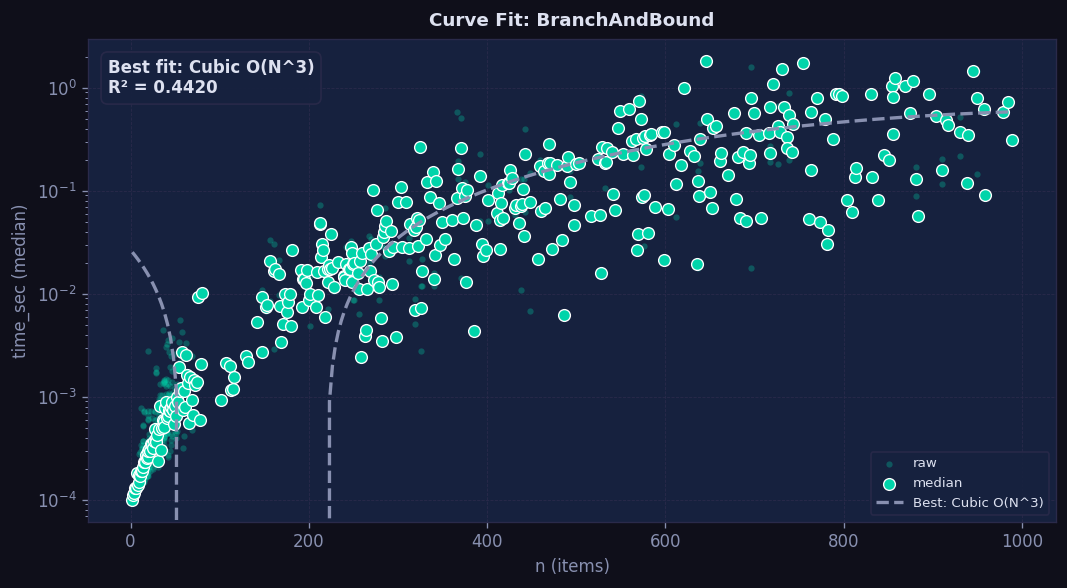

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_DP.png


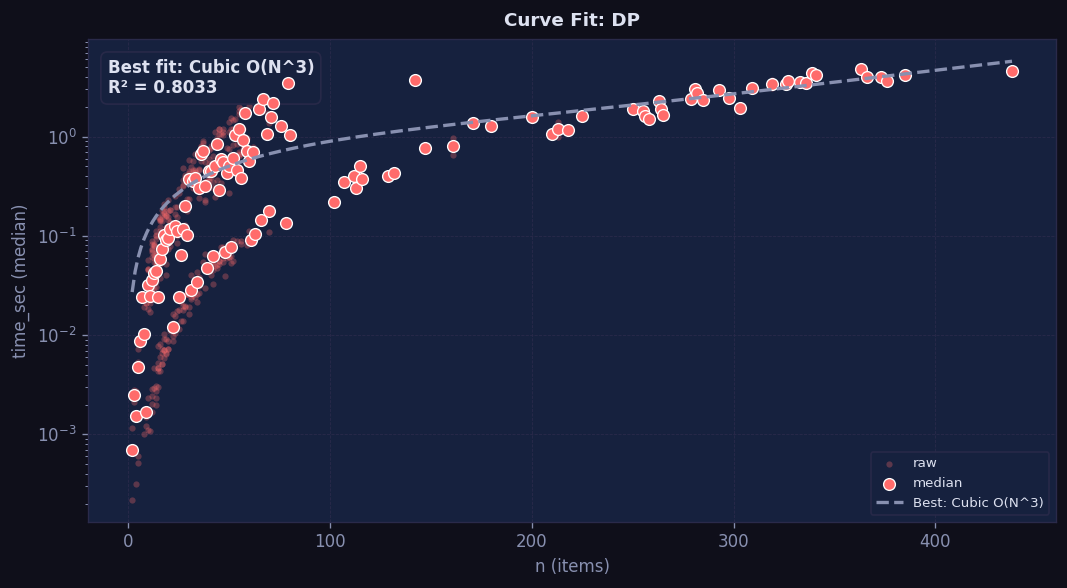

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_DPUnbounded.png


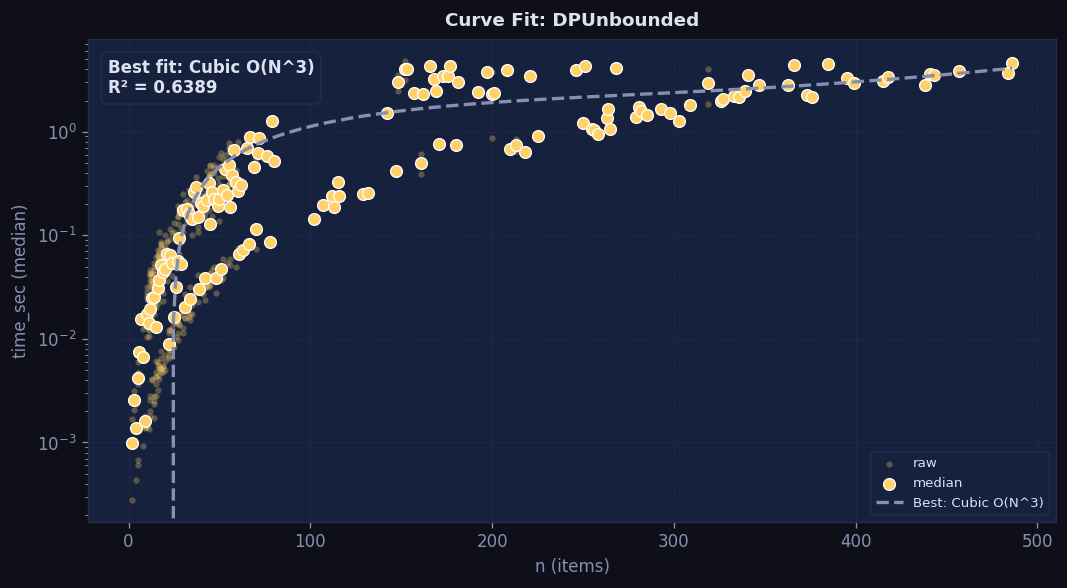

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_DualSimplex.png


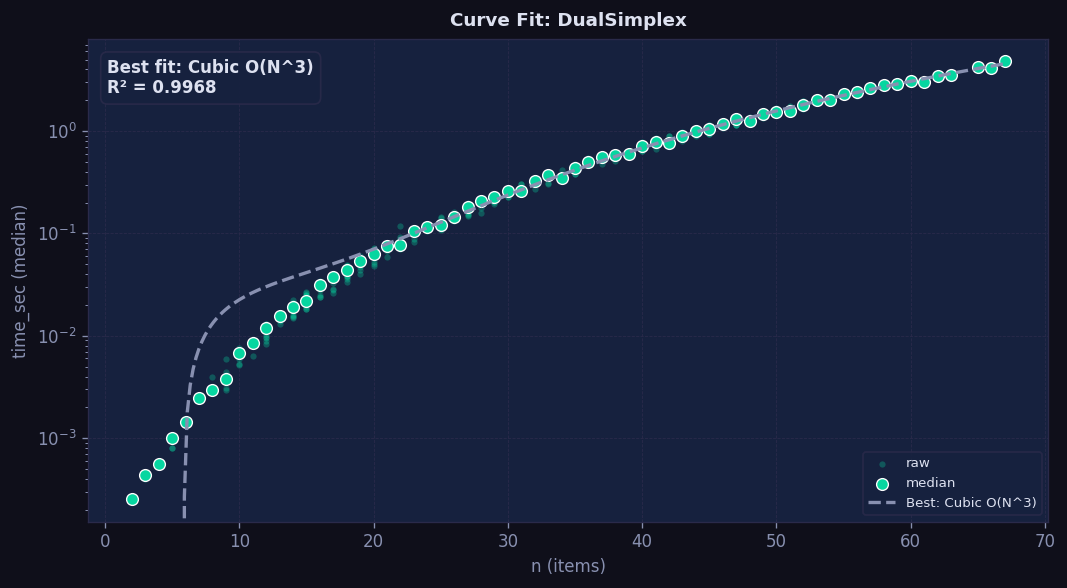

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_GomoryCut.png


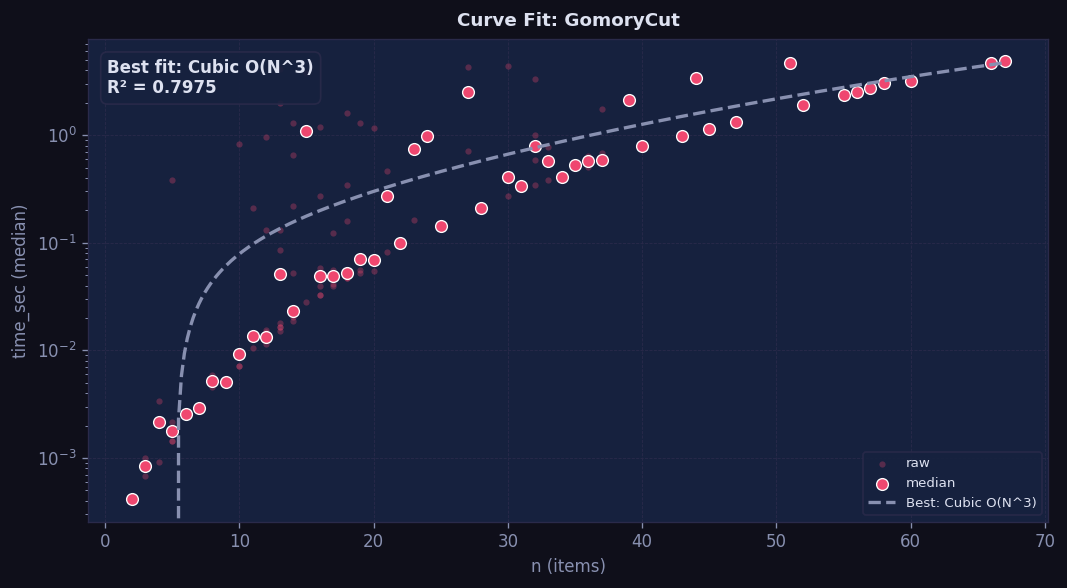

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_Greedy01.png


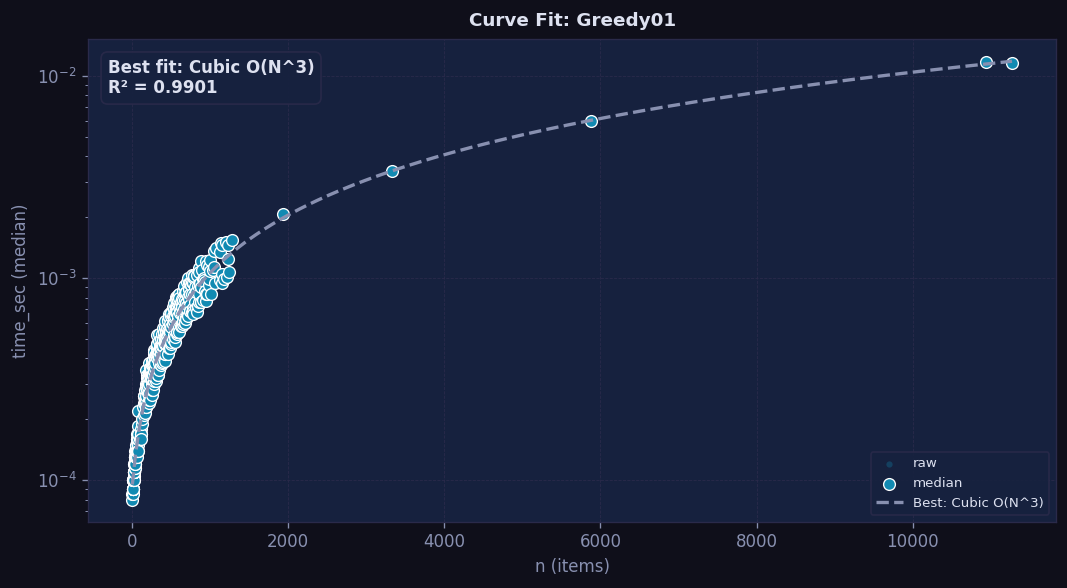

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_GreedyFractional.png


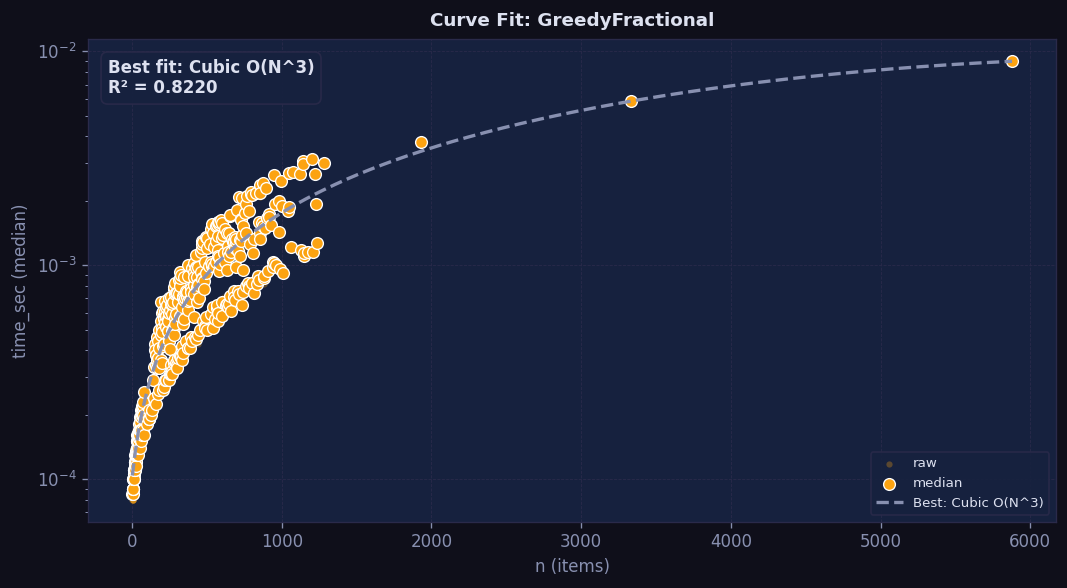

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_PrimalSimplex.png


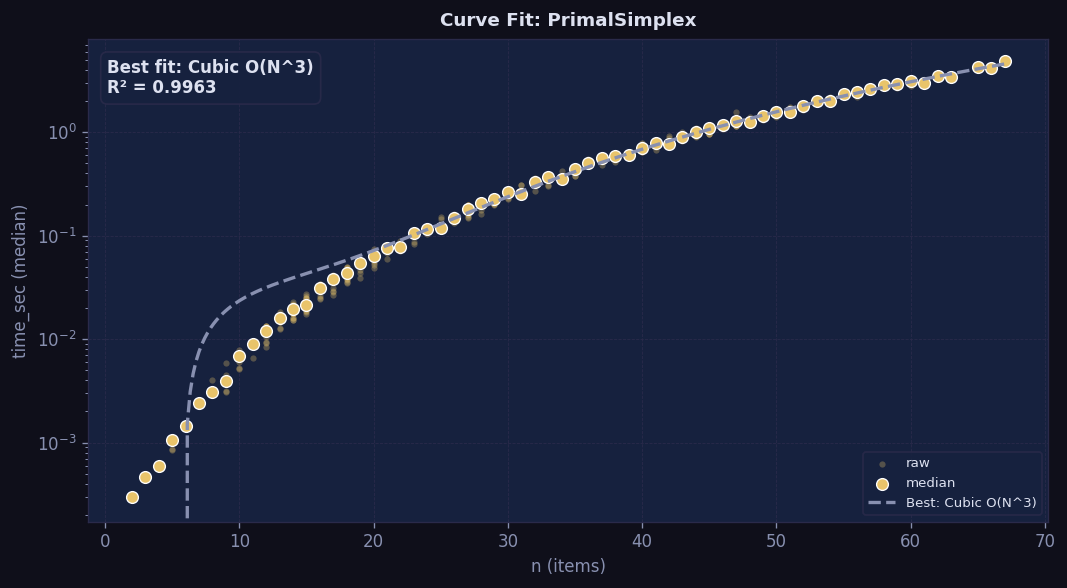

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\curvefit_SimplexBnB.png


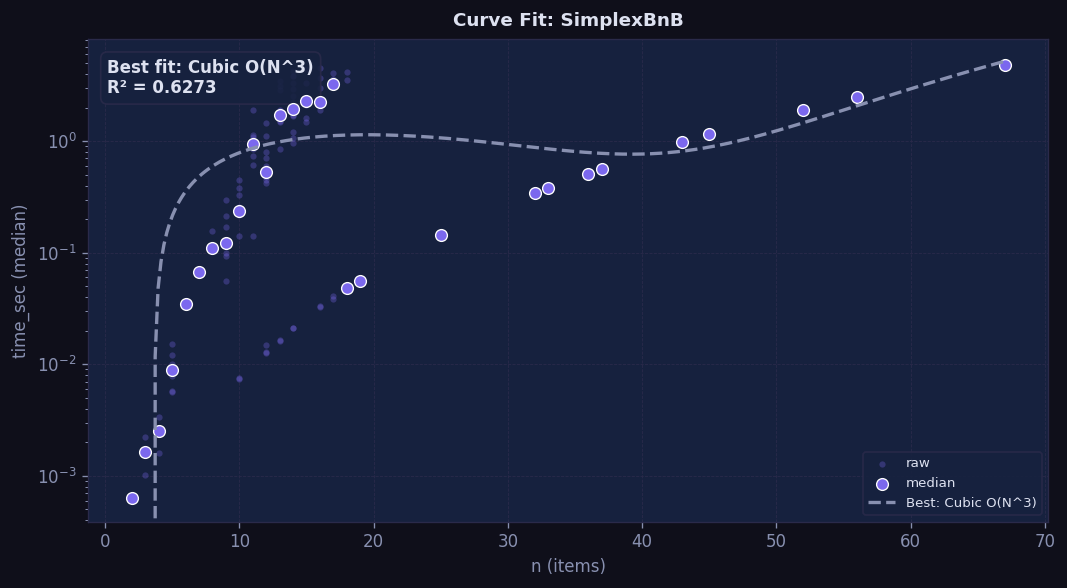

In [4]:
if not HAS_SCIPY:
    print("scipy not available; skip curve fitting.")
else:
    # ── Candidate functions ──────────────────────────────────────────────
    def f_linear(x, a, b):
        return a * x + b

    def f_quad(x, a, b, c):
        return a * x**2 + b * x + c

    def f_cubic(x, a, b, c, d):
        return a * x**3 + b * x**2 + c * x + d

    def f_exp(x, a, b):
        return a * np.power(2.0, b * x)

    CANDIDATES = [
        ("Linear  O(N)",   f_linear, (1e-6, 0),              2),
        ("Quadratic O(N^2)", f_quad, (1e-9, 1e-6, 0),        3),
        ("Cubic O(N^3)",   f_cubic,  (1e-12, 1e-9, 1e-6, 0), 4),
        ("Exponential O(2^N)", f_exp, (1e-6, 0.05),           2),
    ]

    def _r_squared(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

    df_fit = df[df["is_success"] & df["time_sec"].gt(0)].copy()

    for algo in ALGOS:
        sub = df_fit[df_fit["algorithm"] == algo]
        if sub.empty or sub["n"].nunique() < 3:
            continue

        medians = sub.groupby("n")["time_sec"].median().reset_index()
        xd = medians["n"].values.astype(float)
        yd = medians["time_sec"].values.astype(float)

        fig, ax = plt.subplots(figsize=(9, 5), facecolor=FIG_BG)

        # Raw data scatter (all points)
        ax.scatter(sub["n"], sub["time_sec"],
                   s=14, alpha=0.30, color=PAL[algo], linewidths=0, label="raw")
        # Median dots
        ax.scatter(xd, yd, s=50, color=PAL[algo], edgecolors="white",
                   linewidths=0.8, zorder=4, label="median")

        best_name, best_r2, best_ys = "None", -1e9, None

        for name, func, p0, n_params in CANDIDATES:
            if len(xd) < n_params:
                continue
            try:
                popt, _ = curve_fit(func, xd, yd, p0=p0, maxfev=20000)
                x_grid = np.linspace(xd.min(), xd.max(), 300)
                y_pred = func(x_grid, *popt)
                y_pred_pts = func(xd, *popt)
                r2 = _r_squared(yd, y_pred_pts)

                if r2 > best_r2:
                    best_r2 = r2
                    best_name = name
                    best_ys = (x_grid, y_pred)
            except Exception:
                pass

        # Draw best fit
        if best_ys is not None:
            ax.plot(best_ys[0], best_ys[1], "--", color=MUTED_CLR, lw=2,
                    label=f"Best: {best_name}", zorder=5)

        # Annotate
        box_text = f"Best fit: {best_name}\nR² = {best_r2:.4f}"
        ax.text(0.02, 0.96, box_text,
                transform=ax.transAxes, fontsize=10, va="top",
                color=TEXT_CLR, fontweight="bold",
                bbox=dict(facecolor=AX_BG, edgecolor=GRID_CLR,
                          alpha=0.9, boxstyle="round,pad=0.4"))

        tmin, tmax = yd.min(), yd.max()
        if tmax > 0 and tmin > 0 and (tmax / tmin) > 50:
            ax.set_yscale("log")

        ax.legend(fontsize=8, loc="lower right")
        style_ax(ax, f"Curve Fit: {algo}", "n (items)", "time_sec (median)")
        fig.tight_layout()
        save(fig, f"curvefit_{algo}.png")
        plt.show()

## 4 · Comparative Overview Plots

We generate three summary plots to compare algorithms directly:
1. **Execution Status Comparison:** Stacked bar chart of Success, Timeout, and Error rates.
2. **Peak Memory Comparison:** Box plot of maximum memory usage per solver on successful runs.
3. **Median Runtime comparison vs N:** Line plot of median runtime vs N for all solvers.

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\algo_status_comparison.png


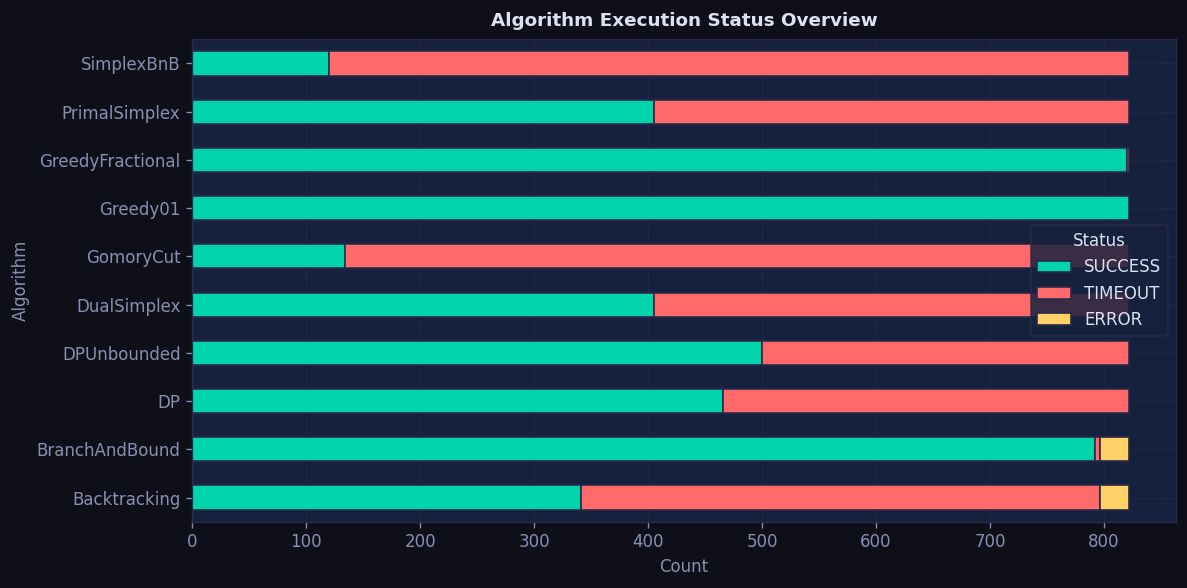

C:\Users\admin\AppData\Local\Temp\ipykernel_11524\1313931632.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\memory_comparison.png


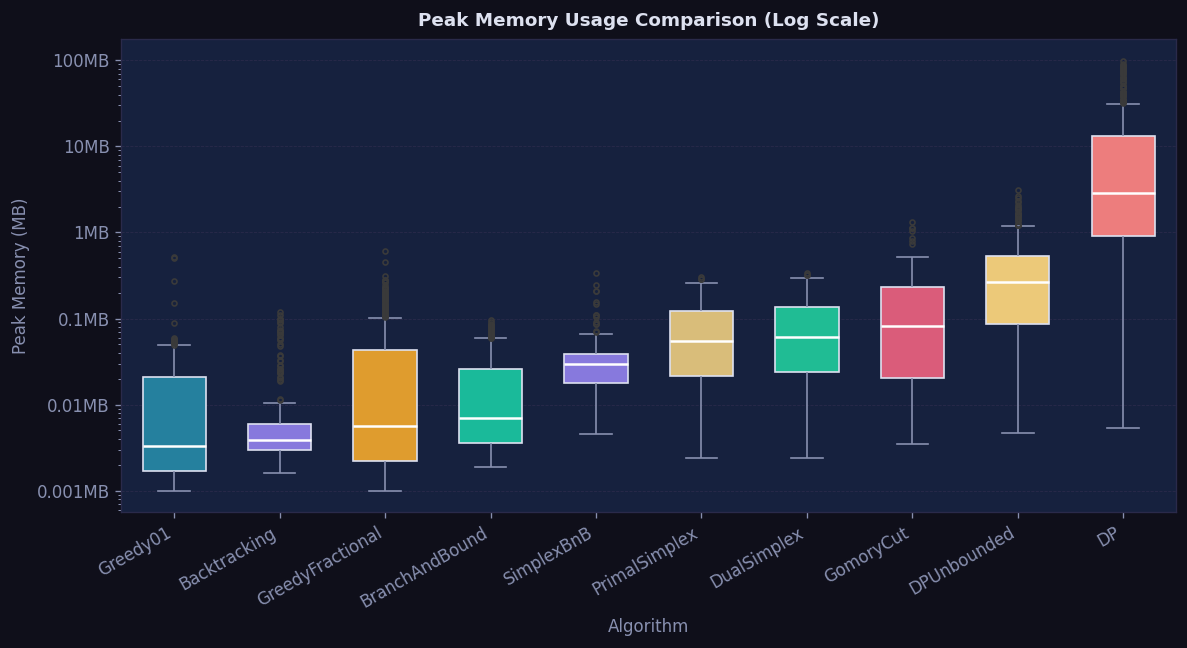

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\runtime_comparison_vs_n.png


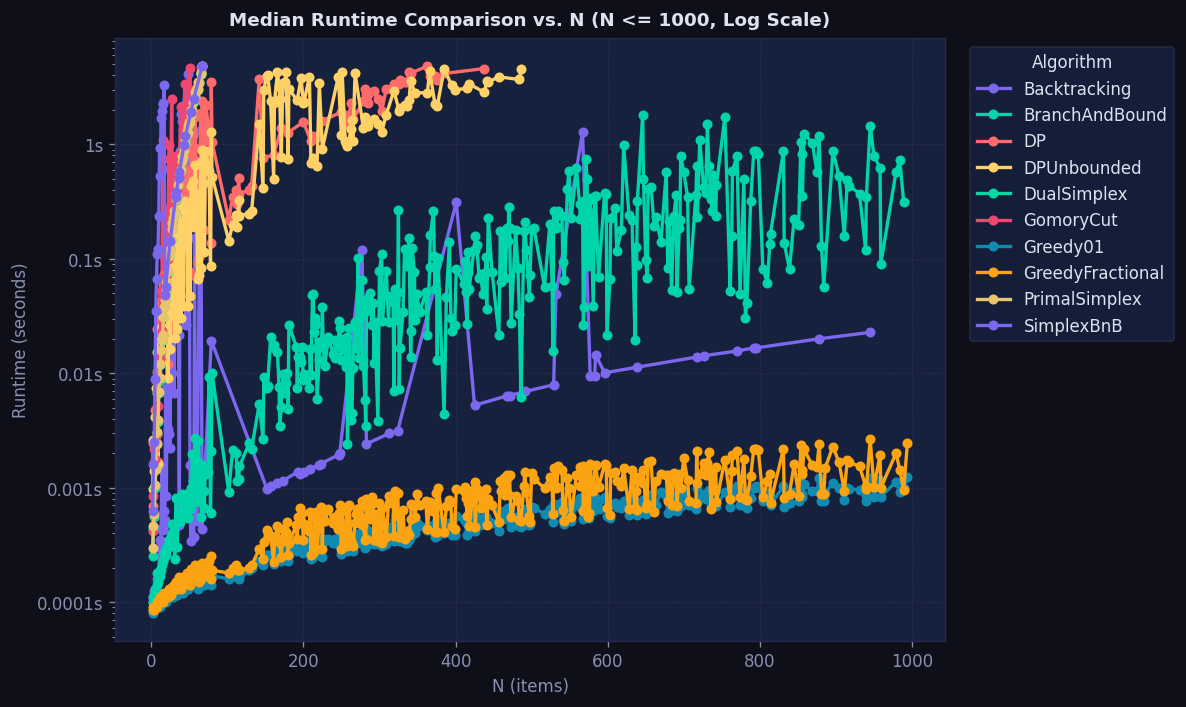

In [5]:
# 1. Execution Status Comparison
fig, ax = plt.subplots(figsize=(10, 5), facecolor=FIG_BG)
status_counts = df.groupby(["algorithm", "status"]).size().unstack(fill_value=0)
for col in ["SUCCESS", "TIMEOUT", "ERROR"]:
    if col not in status_counts.columns:
        status_counts[col] = 0
status_counts = status_counts[["SUCCESS", "TIMEOUT", "ERROR"]]
status_counts.plot(kind="barh", stacked=True, color=["#00d4aa", "#ff6b6b", "#ffd166"], ax=ax, edgecolor=GRID_CLR)
style_ax(ax, "Algorithm Execution Status Overview", "Count", "Algorithm")
ax.legend(title="Status", facecolor=AX_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR)
fig.tight_layout()
save(fig, "algo_status_comparison.png")
plt.show()

# 2. Peak Memory Comparison
df_ok = df[df["is_success"]].copy()
if not df_ok.empty:
    fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=FIG_BG)
    order = df_ok.groupby("algorithm")["peak_memory_mb"].median().sort_values().index
    sns.boxplot(
        data=df_ok, x="algorithm", y="peak_memory_mb", order=order,
        palette=algo_pal(order), ax=ax, width=0.6, fliersize=3,
        boxprops=dict(edgecolor=TEXT_CLR),
        whiskerprops=dict(color=MUTED_CLR),
        capprops=dict(color=MUTED_CLR),
        medianprops=dict(color="white", linewidth=1.5)
    )
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.3g}MB"))
    plt.xticks(rotation=30, ha="right")
    style_ax(ax, "Peak Memory Usage Comparison (Log Scale)", "Algorithm", "Peak Memory (MB)")
    fig.tight_layout()
    save(fig, "memory_comparison.png")
    plt.show()

# 3. Runtime Comparison vs N
fig, ax = plt.subplots(figsize=(10, 6), facecolor=FIG_BG)
for algo in ALGOS:
    sub = df_ok[(df_ok["algorithm"] == algo) & (df_ok["n"] <= 1000)]
    if sub.empty or sub["n"].nunique() < 2:
        continue
    medians = sub.groupby("n")["time_sec"].median().reset_index()
    ax.plot(medians["n"], medians["time_sec"], "o-", color=PAL[algo], label=algo, lw=2, ms=5)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2g}s"))
style_ax(ax, "Median Runtime Comparison vs. N (N <= 1000, Log Scale)", "N (items)", "Runtime (seconds)")
ax.legend(title="Algorithm", facecolor=AX_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
save(fig, "runtime_comparison_vs_n.png")
plt.show()


## 5 · Attribute Correlation & Pairwise Distributions

We generate two statistical plots to analyze our testcases:
1. **Attribute Correlation Heatmap:** Pearson correlation coefficients between input parameters (N, capacity ratio, Pearson R) of the generated testcases.
2. **Pairwise Attribute Distributions (Pairplot):** Joint distributions of N, capacity ratio, and Pearson R across all unique generated instances.

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\correlation_heatmap.png


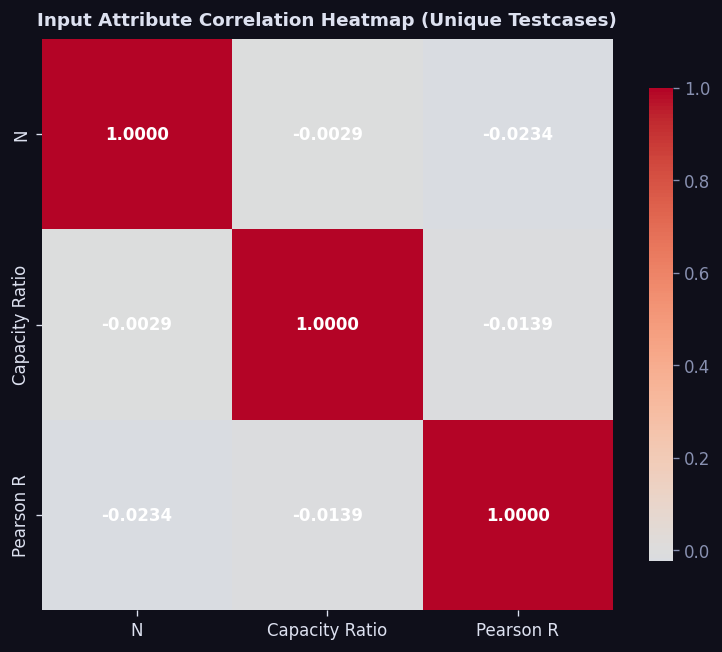

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\attributes_pairplot.png


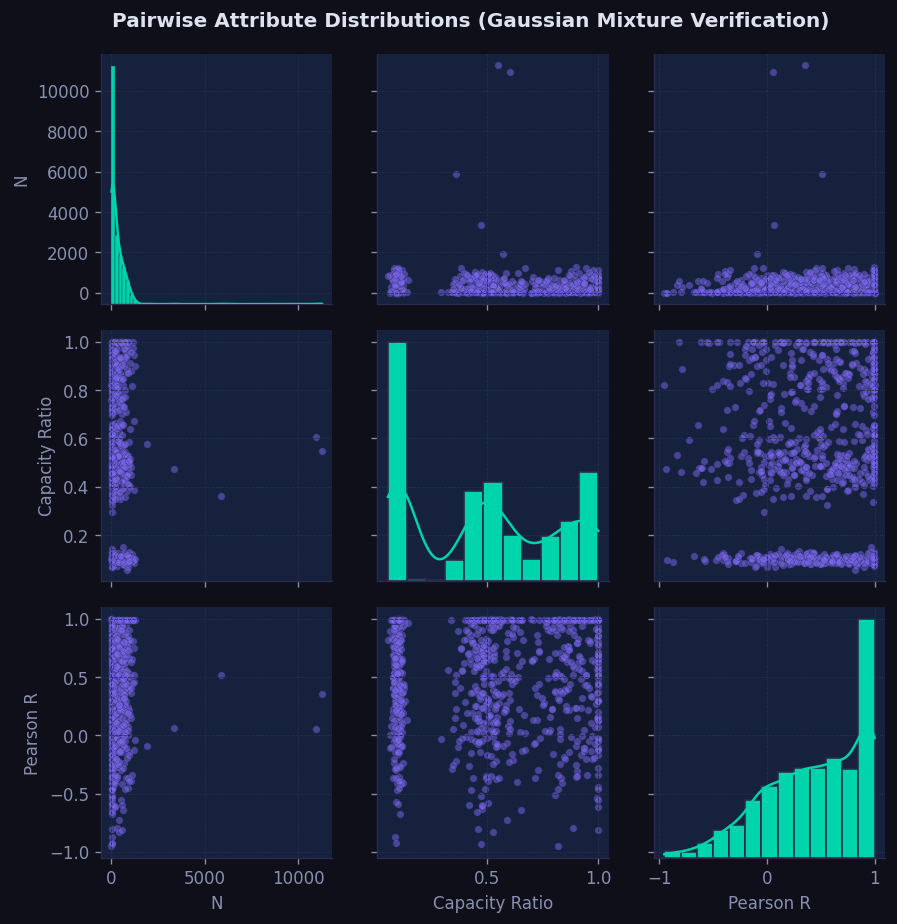

In [6]:
# 1. Correlation Heatmap
df_unique = df.drop_duplicates(subset=["test_id"]).copy()
cols = ["n", "capacity_to_weight_ratio", "pearson_corr"]
corr_cols = {
    "n": "N",
    "capacity_to_weight_ratio": "Capacity Ratio",
    "pearson_corr": "Pearson R"
}
df_corr = df_unique[cols].rename(columns=corr_cols)
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor=FIG_BG)
sns.heatmap(
    corr, annot=True, fmt=".4f", cmap="coolwarm", center=0,
    square=True, ax=ax, cbar_kws={"shrink": .8},
    annot_kws={"size": 10, "weight": "bold", "color": "white"}
)
style_ax(ax, "Input Attribute Correlation Heatmap (Unique Testcases)", "", "")
ax.tick_params(colors=TEXT_CLR)
fig.tight_layout()
save(fig, "correlation_heatmap.png")
plt.show()

# 2. Pairwise Attribute Distributions
df_unique = df.drop_duplicates(subset=["test_id"]).copy()
plot_cols = ["n", "capacity_to_weight_ratio", "pearson_corr"]
df_plot = df_unique[plot_cols].rename(columns={
    "n": "N",
    "capacity_to_weight_ratio": "Capacity Ratio",
    "pearson_corr": "Pearson R"
})

g = sns.PairGrid(df_plot, diag_sharey=False)
g.fig.set_facecolor(FIG_BG)
for ax in g.axes.flat:
    ax.set_facecolor(AX_BG)
    ax.xaxis.grid(True, color=GRID_CLR, linestyle="--", linewidth=0.5)
    ax.yaxis.grid(True, color=GRID_CLR, linestyle="--", linewidth=0.5)
    ax.tick_params(colors=MUTED_CLR)
    ax.xaxis.label.set_color(MUTED_CLR)
    ax.yaxis.label.set_color(MUTED_CLR)

g.map_diag(sns.histplot, color="#00d4aa", kde=True, edgecolor=GRID_CLR, facecolor="#00d4aa", alpha=0.6)
g.map_offdiag(sns.scatterplot, color="#7b68ee", alpha=0.5, s=20, edgecolor=AX_BG, linewidth=0.3)

g.fig.suptitle("Pairwise Attribute Distributions (Gaussian Mixture Verification)", color=TEXT_CLR, fontsize=12, fontweight="bold", y=1.02)
g.savefig(PLOTS / "attributes_pairplot.png", dpi=300, bbox_inches="tight", facecolor=FIG_BG)
print(f"Saved -> {PLOTS / 'attributes_pairplot.png'}")
plt.show()
